In [186]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Let's import the fhn model
from neurolib.models.fhn import FHNModel
from neurolib.models.aln import ALNModel
from neurolib.utils import costFunctions as cost
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [162]:
from neurolib.utils import costFunctions as cost

cost.setDefaultParams()
print(cost.getParams())
cost.setParams(1.0, 0.001, 0.)
print(cost.getParams())

set default params
(1.0, 1.0, 1.0)
set params
(1.0, 0.001, 0.0)


In [163]:
fhn = FHNModel()

c_mat = np.array([[0.]])
c_scheme = np.zeros((len(fhn.output_vars), len(fhn.output_vars) ))
c_scheme[0,0] = 1.

u_mat = np.identity(fhn.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

duration = 10.

fhn.params['duration'] = duration
            
state0 = fhn.getZeroState()
target = fhn.getZeroTarget()
control0 = fhn.getZeroControl()
for i in range(control0.shape[2]):
    control0[:,:,i] = 0.01*i

fhn.run(control = control0)

target_vars = fhn.target_output_vars
output_vars = fhn.output_vars

for o_ind in range(len(output_vars)):
    for t_ind in range(len(target_vars)):
        if (target_vars[t_ind] == output_vars[o_ind]):
            target[:,t_ind,:] = fhn[output_vars[o_ind]][:,:]

control1 = fhn.getZeroControl()
fhn.run()

for o_ind in range(len(output_vars)):
    state0[:,o_ind,:] = fhn[output_vars[o_ind]][:,:]

RUN  0 , total integrated cost:  0.00169175
RUN  1 , total integrated cost:  0.0016479722375133544
RUN  2 , total integrated cost:  0.0016402133833839886
RUN  3 , total integrated cost:  0.0016386826324871744
RUN  4 , total integrated cost:  0.001638304652543446
RUN  5 , total integrated cost:  0.00163822502678546
RUN  6 , total integrated cost:  0.0016382083527672283
RUN  7 , total integrated cost:  0.0016382044240200525
RUN  8 , total integrated cost:  0.001638203584721736
RUN  9 , total integrated cost:  0.0016382034147370069
RUN  10 , total integrated cost:  0.0016382033836842022
RUN  11 , total integrated cost:  0.001638203380091252
Control only changes marginally.
Improved over  11  iterations by  4  percent.


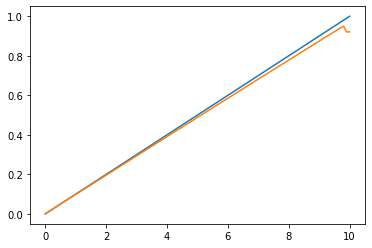

In [164]:
tolerance = 1e-6
incl_steps = int(1. + duration/fhn.params.dt)
max_iteration = 20

A2_bestControl, A2_bestState, A2_cost, A2_runtime = fhn.A2(control0, target, max_iteration,
                                                                          tolerance, incl_steps)

plt.plot(fhn.t, control0[0,0,:])
plt.plot(fhn.t, A2_bestControl[0,0,:])

RUN  0 , total integrated cost =  1.69175
RUN  1 , total integrated cost =  0.10573437500000002
descent condition min, max, mean =  -0.0625 0.0 -0.020937500000000005
RUN  2 , total integrated cost =  0.0066083984374999995
descent condition min, max, mean =  -0.00390625 0.0 -0.00130859375
RUN  3 , total integrated cost =  0.00041302490234374997
descent condition min, max, mean =  -0.000244140625 0.0 -8.1787109375e-05
RUN  4 , total integrated cost =  2.5814056396484373e-05
descent condition min, max, mean =  -1.52587890625e-05 0.0 -5.1116943359375e-06
RUN  5 , total integrated cost =  1.6133785247802733e-06
descent condition min, max, mean =  -9.5367431640625e-07 0.0 -3.1948089599609377e-07
RUN  6 , total integrated cost =  1.0083615779876708e-07
descent condition min, max, mean =  -5.960464477539063e-08 0.0 -1.996755599975586e-08
RUN  7 , total integrated cost =  6.302259862422943e-09
descent condition min, max, mean =  -3.725290298461914e-09 0.0 -1.2479722499847413e-09
RUN  8 , total 

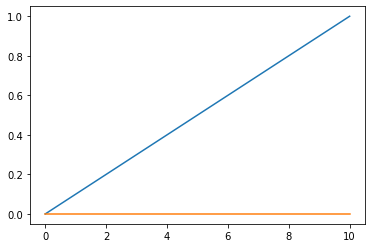

In [149]:
A1_bestControl, A1_bestState, A1_cost, A1_runtime = fhn.A1(state0, target, control0, c_scheme, u_mat, u_scheme, max_iteration_ = 10,
                                    tolerance_ = 1.e-6, startStep_ = 10., test_step_ = 1e-12, cntrl_max_ = 20.,
                                    CGVar = None)

plt.plot(fhn.t, control0[0,0,:])
plt.plot(fhn.t, A1_bestControl[0,0,:])

In [165]:
for i in [0]:
    print(i)

0


In [168]:
for n in np.array([control1.shape[0]]):
    print(n)

1


In [202]:
model = ALNModel()
assertion_tolerance = 5
        
controlmin, controlmax = -2., 2.
duration = 0.7
algorithm_tolerance = 1e-16
incl_steps = int(1. + duration/model.params.dt)
max_iteration = int(1e2)
start_step = 10.
test_step = 1e-12

model.params.duration = duration

if (model.name == "aln"):
    model.params.signalV = 0.
    model.params.de = 0.
    model.params.di = 0.

state0 = model.getZeroState()
state1 = state0.copy()
state2 = state0.copy()
target = model.getZeroTarget()
control0 = model.getZeroControl()
control1 = control0.copy()
control2 = control0.copy()
        
target_vars = model.target_output_vars
output_vars = model.output_vars


model.params.duration = duration
        
def getRandomControl():
    control_ = model.getZeroControl()
    for n in range(control_.shape[0]):
         for v in range(control_.shape[1]):
            for t in range(control_.shape[2]):
                control_[n, v, t] = random.uniform(controlmin, controlmax)
    return control_
    
def updateState(control_):
    state_ = model.getZeroState()
    model.run(control = control_)
    for o_ind in range(len(output_vars)):
        state_[:,o_ind,:] = model[output_vars[o_ind]][:,:]
    return state_
        
    
def setTargetFromControl(control_):
    target_ = model.getZeroTarget()
    model.run(control = control_)
    for o_ind in range(len(output_vars)):
        for t_ind in range(len(target_vars)):
            if (target_vars[t_ind] == output_vars[o_ind]):
                target_[:,t_ind,:] = model[output_vars[o_ind]][:,:]
    return target_
        
        
model.params.duration = duration
        
control1 = getRandomControl()    
target = setTargetFromControl(control1)    
control2 = getRandomControl()
        
testip, testie, testis = 1., 0., 0.
cost.setParams(testip, testie, testis)

A2_bestControl, A2_bestState, A2_cost, A2_runtime = model.A2(control2, target, max_iteration,
                                                                          algorithm_tolerance, incl_steps, start_step, test_step)
        
for n in range(A2_bestControl.shape[0]):
    for v in range(A2_bestControl.shape[1]):
        for t in range(A2_bestControl.shape[2] - 1):
            print(n, v, t)
            print(A2_bestControl[n, v, t] - control1[n, v, t])
        

set cost params
RUN  0 , total integrated cost:  53.560653648665216
RUN  1 , total integrated cost:  53.16493878868245
RUN  2 , total integrated cost:  11.589108697086084
RUN  3 , total integrated cost:  9.47408791272269
RUN  4 , total integrated cost:  10.456557380438174
RUN  5 , total integrated cost:  11.501623711317743
RUN  6 , total integrated cost:  12.822797026865416
RUN  7 , total integrated cost:  13.662221092487858
RUN  8 , total integrated cost:  14.424854392101548
RUN  9 , total integrated cost:  15.297355829478724
RUN  10 , total integrated cost:  15.857267680858397
RUN  11 , total integrated cost:  16.481434503662683
RUN  12 , total integrated cost:  16.818715020531858
RUN  13 , total integrated cost:  16.975585303882305
RUN  14 , total integrated cost:  17.155449137258064
RUN  15 , total integrated cost:  17.33532478253874
RUN  16 , total integrated cost:  17.523059346176954
RUN  17 , total integrated cost:  17.622038567836228
RUN  18 , total integrated cost:  17.8008435

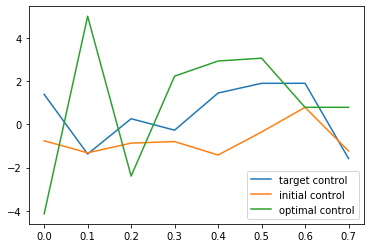

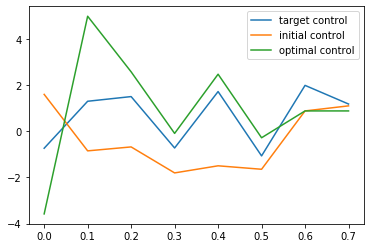

In [203]:
plt.plot(model.t, control1[0,0,:], label = "target control")
plt.plot(model.t, control2[0,0,:], label = "initial control")
plt.plot(model.t, A2_bestControl[0,0,:], label = "optimal control")
plt.legend()
plt.show()

plt.plot(model.t, control1[0,1,:], label = "target control")
plt.plot(model.t, control2[0,1,:], label = "initial control")
plt.plot(model.t, A2_bestControl[0,1,:], label = "optimal control")
plt.legend()
plt.show()